In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

In [2]:
# open files
path = "/global/homes/n/nagarwal/graph-ufs/prototypes/ocn_only"

bathy=xr.open_dataset(os.path.join(path, "topog.nc")) # central topography file
edits=xr.open_dataset(os.path.join(path, "All_edits.nc")) # edits in the above

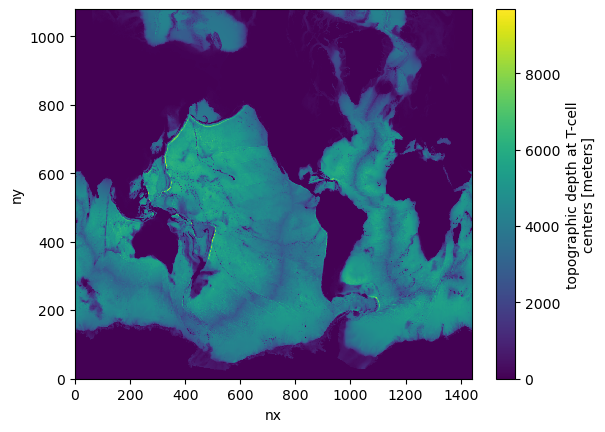

In [3]:
bathy.depth.plot()
plt.show()

In [4]:
# edit bathymetry
for i in edits.nEdits.values:
    bathy.depth[edits.jEdit[i].values, edits.iEdit[i].values]=abs(edits.zEdit[i].values)

In [5]:
# set max and min depths (as done in MOM6)
bathy.depth[:,:]=xr.where(bathy.depth < 9.5,9.5,bathy.depth)
bathy.depth[:,:]=xr.where(bathy.depth > 6500,6500,bathy.depth)

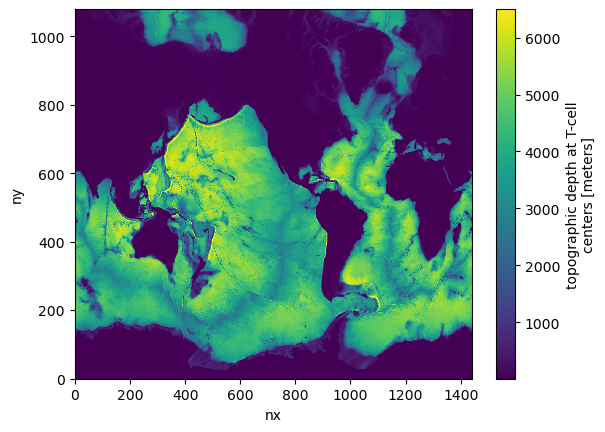

In [6]:
bathy.depth.plot()
plt.show()

In [10]:
bathy.to_netcdf(os.path.join(path, "topog_all_edited.nc"))